In [6]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
from scipy.interpolate import interp1d

from collections import defaultdict
import pyBigWig as pw
from matplotlib_venn import venn2
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
import scipy.stats as stats
import pickle
matplotlib.rcParams['pdf.fonttype'] = 42

In [3]:
os.makedirs('figures/Fig7/', exist_ok=True)

In [10]:

with open('data/auxilary/nuc_struct.pkl', 'rb') as f:
    nucchr = pd.DataFrame(pickle.load(f))
gp = pd.read_csv('data/auxilary/geneinfo_params.csv', index_col=0)
aligner = Align.PairwiseAligner()


In [55]:
def align_mots(ref, seq2, aligner=aligner):
    aligned_F = aligner.align(ref, seq2)
    aligned_R = aligner.align(ref, Seq(seq2).reverse_complement())
    
    if aligned_F.score >= aligned_R.score:
        return "+"
    else:
        return "-"

def load_mot(path, mot_path):
    with open(mot_path) as handle:
        cosensus_mot = motifs.read(handle, "pfm-four-columns").consensus

        # Extract the motif sequences (not specifically used below)
    loaded_loc = pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3,: ]#.loc[:, ['motif_id', 'sequence_name', 'start', 'stop', 'strand', 'matched_sequence']]
    seqs = loaded_loc.loc[:, 'matched_sequence']
    # loaded_loc['strand'] = seqs.apply(lambda x: align_mots(cosensus_mot, x, aligner)).values
    return loaded_loc

    
def proc_mot_in_porms(ppath, mean_data, cmotif):
    with open(cmotif) as handle:
        cosensus_mot = motifs.read(handle, "pfm-four-columns").consensus
    prom_mots = pd.read_csv(ppath, index_col=0)
    prom_mots.loc[:, 'Mid'] = np.ceil(prom_mots.Start_b + (prom_mots.End_b - prom_mots.Start_b)/2)
    seqs = prom_mots.loc[:, 'Name_b']
    # prom_mots.loc[:, 'Strand'] = seqs.apply(lambda x: align_mots(cosensus_mot, x, aligner)).values
    
    dl = dict()
    for tf in mean_data.columns:

        window = 100
        l=[]
        for i in prom_mots.iloc[:, [0,-3,-1]].to_numpy():

            sig = pd.DataFrame(mean_data.loc[:, tf]).apply(lambda x: x.loc[i[0]][int(i[2]-window) : int(i[2]+window)])
            if i[1] == '+':
                l.append(sig.T.values[0])
            else:
                l.append(sig[::-1].T.values[0])
        dl[tf] = pd.DataFrame(l, index=prom_mots.index)

    return dl
def compute_footprint_lengths(x, y, thresholds):
    """
    Compute footprint lengths for multiple percentage thresholds.
    
    Parameters:
        x (array-like): X-values (time or index)
        y (array-like): Y-values (signal intensity)
        thresholds (list): List of percentage drop values (e.g., [0.05, 0.1, 0.5])

    Returns:
        footprint_lengths (dict): Dictionary with thresholds as keys and footprint lengths as values.
    """
    # Interpolation function
    interp_func = interp1d(x, y, kind='linear')

    # Generate more dense x values for interpolation
    window = 600
    x_dense = np.linspace(min(x), max(x), window)
    y_dense = interp_func(x_dense)  # Interpolated y values

    # Find Peak
    peak_index = int(window/2)
    peak_x = x_dense[peak_index]
    peak_y = y_dense[peak_index]

    footprint_lengths = {}

    for threshold in thresholds:
        threshold_value = threshold * peak_y  # Compute threshold level

        # Find left and right drop-off points safely
        left_indices = np.where(y_dense[:peak_index] <= threshold_value)[0]
        right_indices = np.where(y_dense[peak_index:] <= threshold_value)[0]

        left_x = x_dense[left_indices[-1]] if len(left_indices) > 0 else None
        right_x = x_dense[right_indices[0] + peak_index] if len(right_indices) > 0 else None

        # Compute footprint length if both sides exist
        footprint_length = right_x - left_x if left_x is not None and right_x is not None else None

        footprint_lengths[threshold] = footprint_length

    return footprint_lengths

def find_gap_length(series, threshold):
    """
    Finds the length of the largest gap in the given series where values are below a threshold.

    Parameters:
    series (pd.Series): The mean signal data.
    threshold (float): The value below which the signal is considered absent.

    Returns:
    int: Length of the largest contiguous gap.
    """
    below_threshold = series < threshold  # Boolean mask where values are below the threshold
    gap_lengths = []  # Store lengths of gaps
    current_length = 0

    for is_below in below_threshold:
        if is_below:
            current_length += 1
        else:
            if current_length > 0:
                gap_lengths.append(current_length)
                current_length = 0

    if current_length > 0:  # Catch gap at the end
        gap_lengths.append(current_length)

    return max(gap_lengths, default=0)

def draw_arrow(ax, coords, hw, hl, wd, ya,s, text):
    start = coords[0]
    stop = coords[1]
    if (start-stop) > 0:
        ax.arrow(start, ya, -(start-stop)+hl,0, head_width=hw, head_length=hl, width=wd, fc='gainsboro', ec='black', lw=.5)
    else:
        ax.arrow(start, ya, (stop-start)-hl,0, head_width=hw, head_length=hl, width=wd, fc='gainsboro', ec='black', lw=.5)
    ax.text((min(start,stop)+np.abs(stop-start)/4), ya+10, text, size=s)

def draw_line(ax, coord, c='k', lw=.5, ls='--'):
    ax.axvline(coord, c=c, lw=lw, ls=ls)
    
def draw_promoter(chrom, start_gene,lim_data, mean_data, nucchr=nucchr,  title='', save=False, gp=gp,):
    chrom = chrom
    startchr = start_gene-4000
    stopchr = start_gene+4000
    genecoords = (gp.query("chr_loc==@chrom & start>@startchr & stop<@stopchr & status=='Verified ORF'").loc[:, ['start', 'stop']].applymap(lambda x: int(x)) - startchr).clip(0)

    tracks = mean_data.loc[chrom].apply(lambda x: x[startchr:stopchr])
    fig, ax = plt.subplots(tracks.shape[0]+2,1, constrained_layout=False, sharex=True, sharey=False, dpi=150, figsize=(5,3))

    m_track = tracks.apply(lambda x: max(x))

    
    colors = ['indigo', 'maroon', 'chocolate', 'darkgreen', 'navy', 'steelblue', 'pink', 'royalblue', 'olive']
    
    maxy = []
    for tfi, axi, colori in zip(mean_data.columns, ax[1:], colors):
        plot_vec = tracks.loc[tfi]
        axi.fill_between(np.arange(plot_vec.shape[0]), plot_vec,color=colori,lw=.8)
        sns.despine(ax=axi, top=True, right=True)
        axi.set_ylabel(tfi, size=6, rotation=0, labelpad=20)
        axi.yaxis.label.set_color(colori)
        axi.set_xlim([-10,stopchr-startchr])
        # axi.set_ylim([-5, ])
        
        if m_track.loc[tfi] > lim_data[tfi]:
            axi.set_ylim([-5, m_track.loc[tfi]])
            maxy.append(m_track.loc[tfi])
        else:
            axi.set_ylim([-5, lim_data[tfi]])
            maxy.append(lim_data[tfi])
        axi.set_yticklabels(axi.get_yticklabels(), size=5)
        axi.tick_params(bottom=False, left=False)
    ax[0].set_ylim([0, 100])
    hw = 30
    hl = 50
    wd = 10
    ya = 50
    ts = 5
    for i in range(genecoords.shape[0]):
        text = genecoords.index[i]
        draw_arrow(ax[0], genecoords.values[i], hw, hl, wd, ya, ts, text)
        for axi in ax[1:]:
            draw_line(axi, genecoords.values[i][0])

    ax[0].tick_params(bottom=False, left=False)

    ax[0].set_yticklabels('')
    sns.despine(ax=ax[0], top=True, right=True, bottom=True, left=True)


    ax[-1].fill_between(range(stopchr-startchr), nucchr.loc[chrom].apply(lambda x: x[startchr:stopchr]).values[0], color='gainsboro')
    ax[-1].set_yticklabels('')
    ax[-1].set_ylabel('MNase-seq', size=6, rotation=0, labelpad=20)
    ax[-1].set_xticklabels('')
    ax[-1].tick_params(bottom=False, left=False)

    sns.despine(ax=ax[-1], top=True, right=True, bottom=False)
    fig.subplots_adjust(hspace=0.2)

    y = max(tracks.apply(lambda x: max(x))) * 0.7
    
    y = maxy[0] * 0.7
    ax[1].plot([(stopchr-startchr)-1000,(stopchr-startchr)-500],[y,y], c='k')
    ax[1].text((stopchr-startchr)-1000, y+2, '500bp', size=7)

    ax[-1].set_xlabel('Chr{} {}..{} ({}kb)'.format(chrom, startchr, stopchr, (stopchr-startchr)/1000), size=6)
    
    if save:
        fig.savefig('figures/Fig7/{}.pdf'.format(save))

In [12]:
motd = {        'GR_NR':    'data/combined_threshed_peaks_wsummits/output_homer_nmumg_hgr_wt_lig_fc10.bed/homerResults/motif3.motif',
            'GR_halfsite':'data/combined_threshed_peaks_wsummits/output_homer_nmumg_hgr_dbd_fc10.bed/homerResults/motif4.motif',
        'GR_FOX':   'data/combined_threshed_peaks_wsummits/output_homer_nmumg_hgr_wt_lig_fc10.bed/homerResults/motif5.motif',    
        'GR_AP1':   'data/combined_threshed_peaks_wsummits/output_homer_nmumg_hgr_wt_lig_fc10.bed/homerResults/motif1.motif',
              'GR_KLF':'data/combined_threshed_peaks_wsummits/output_homer_nmumg_hgr_wt_lig_fc10.bed/homerResults/motif2.motif',

    }


In [32]:
complete_set_reps = pd.read_parquet('data/yeast/new_sumprom_reps.parquet')
complete_set_reps = complete_set_reps.drop(complete_set_reps.filter(regex='en').columns, axis=1)
complete_set_reps.columns = ['_'.join(x[:-2]) for x in complete_set_reps.columns.str.split('_')]
complete_set_reps.columns =  complete_set_reps.columns.map(lambda x: x.replace('_into_HO', '').replace('__', '_'))

mean_sp = complete_set = pd.read_parquet('data/yeast/new_sumprom_means.parquet')

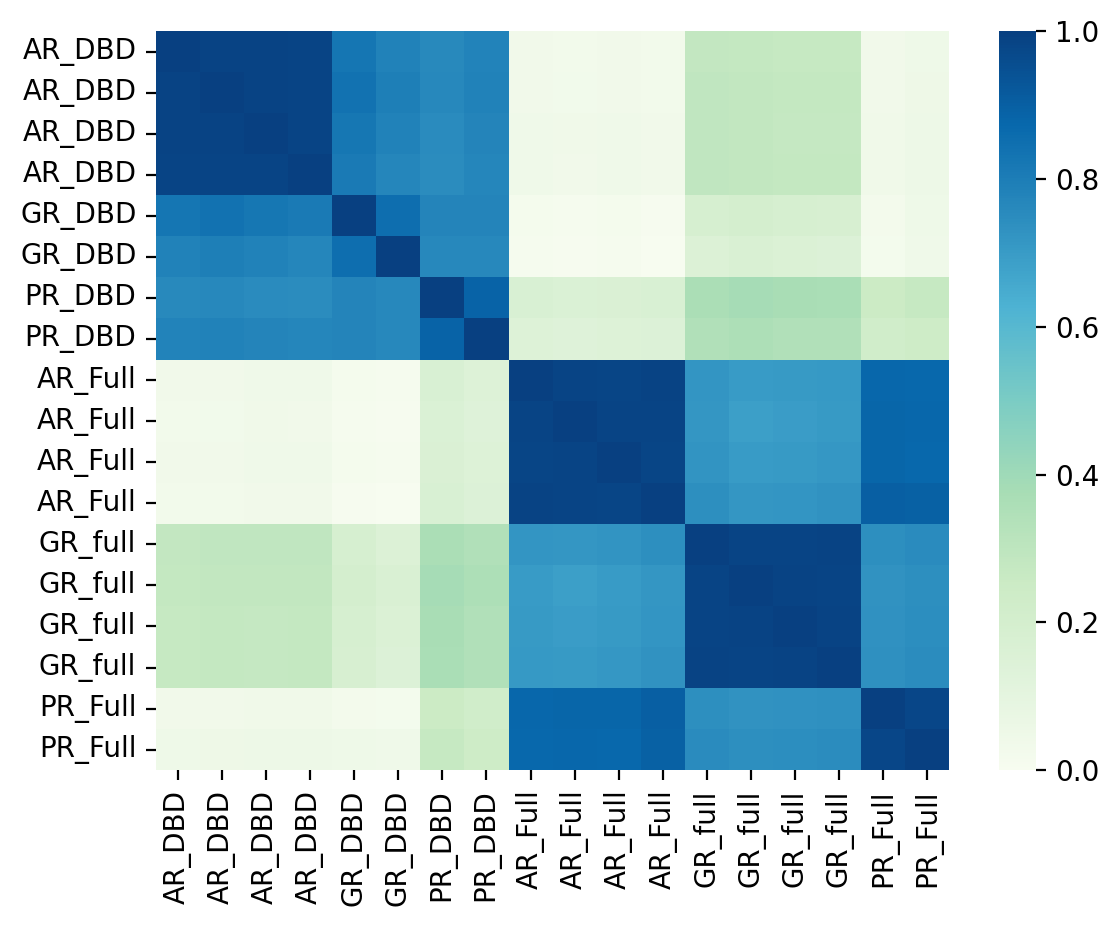

In [29]:
l = ['AR_DBD',  'GR_DBD','PR_DBD', 'AR_Full', 'GR_full',  'PR_Full']
fig, ax = plt.subplots(1)
sns.heatmap(complete_set_reps.loc[:, l].corr(), cmap='GnBu', vmin=0, ax=ax)
fig.savefig('figures/Fig7/7C.pdf')

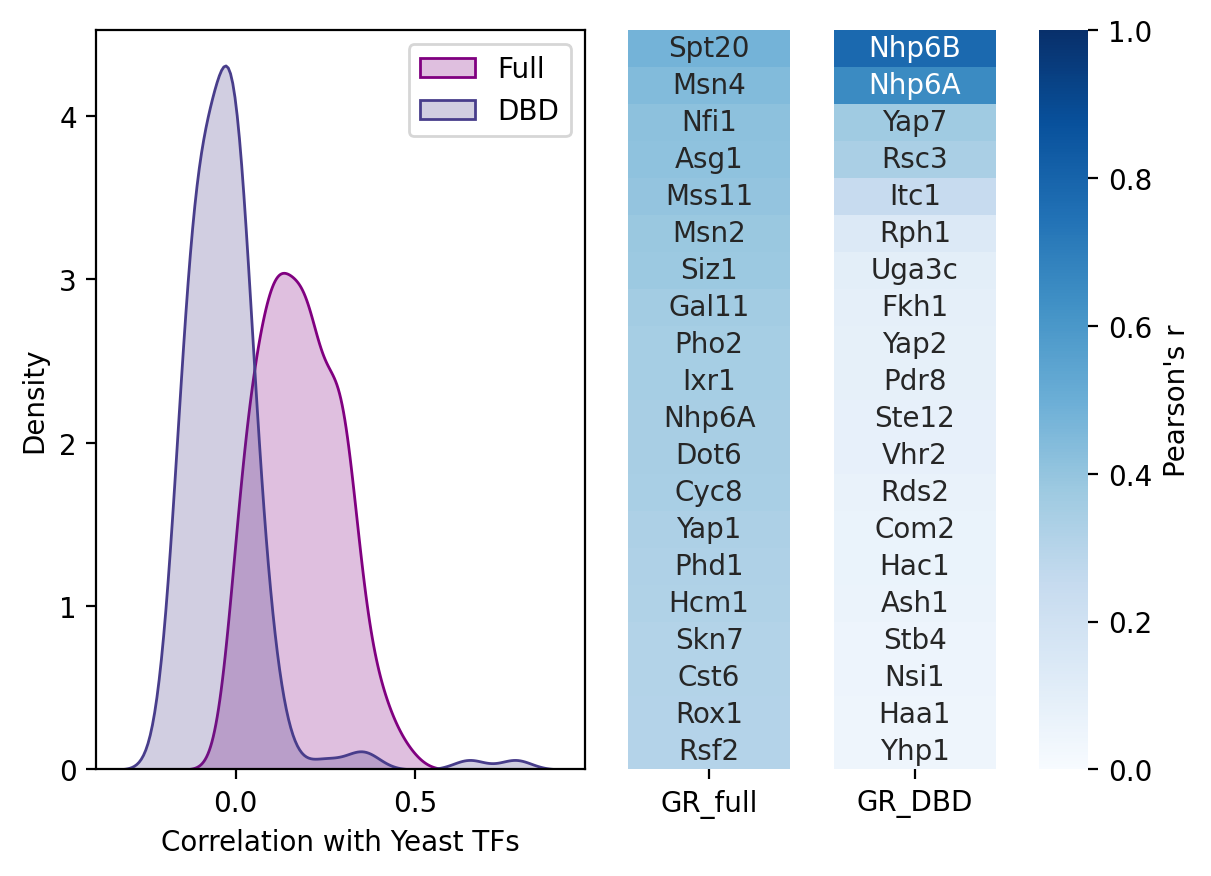

In [34]:
sumproms_all = glob.glob('data/yeast/all_tf_sp/*.gz')
sumproms_all_df = pd.concat([pd.read_parquet(x) for x in sumproms_all], axis=1)

fig, (ax,ax1,ax2, ax3) = plt.subplots(1,4, width_ratios=[3,1,1,.3])
sns.kdeplot(pd.concat([sumproms_all_df, mean_sp.loc[:, 'GR_full']], axis=1).corr().sort_values(by='GR_full', ascending=False).loc[:, 'GR_full'].drop('GR_full'), ax=ax, common_norm=False, fill=True, color='purple', label='Full')
sns.kdeplot(pd.concat([sumproms_all_df, mean_sp.loc[:, 'GR_DBD']], axis=1).corr().sort_values(by='GR_DBD', ascending=False).loc[:, 'GR_DBD'].drop('GR_DBD'), ax=ax, common_norm=False, fill=True, color='darkslateblue', label='DBD')
ax.legend()
ax.set_xlabel('Correlation with Yeast TFs')

ftop = pd.DataFrame(pd.concat([sumproms_all_df, mean_sp.loc[:, 'GR_full']], axis=1).corr().sort_values(by='GR_full', ascending=False).loc[:, 'GR_full'].drop('GR_full').iloc[:20])
dtop = pd.DataFrame(pd.concat([sumproms_all_df, mean_sp.loc[:, 'GR_DBD']], axis=1).corr().sort_values(by='GR_DBD', ascending=False).loc[:, 'GR_DBD'].drop('GR_DBD').iloc[:20])
     
sns.heatmap(ftop, ax=ax1, yticklabels=False, cbar=False, vmin=0, vmax=1, annot=np.array(ftop.index).reshape(-1,1), fmt='', cmap='Blues')
sns.heatmap(dtop, ax=ax2, yticklabels=False, cbar_ax=ax3, vmin=0, vmax=1,annot=np.array(dtop.index).reshape(-1,1), fmt='', cmap='Blues', cbar_kws={"label":'Pearson\'s r'})

fig.savefig('figures/Fig7/7G.pdf')

In [38]:
norms = glob.glob('data/yeast/norms/norm_*.gz')
norms = pd.DataFrame({x.split('norm_')[-1].split('.')[0]:x for x in norms}, index=['norms']).T


In [39]:
fulllist = ['ARDBD_en_1_S13', 'ARDBD_en_2_S14', 'ARDBD_en_3_S15', 'ARDBD_en_4_S16',
       'AR_DBD_into_HO_1_S97', 'AR_DBD_into_HO_2_S98', 'AR_DBD_into_HO_3_S99',
       'AR_DBD_into_HO_4_S100', 'AR_Full_into_HO_1_S89',
       'AR_Full_into_HO_2_S90', 'AR_Full_into_HO_3_S91',
       'AR_Full_into_HO_4_S92', 'ARfull_en_2_S26', 'ARfull_en_4_S28'] + ['GR_160_240_1_S104', 'GR_160_240_3_S106', 'GR_1_60_1_S98',
       'GR_1_60_2_S99', 'GR_1_60_3_S100', 'GR_200_260_2_S108',
       'GR_200_260_3_S109', 'GR_240_300_1_S110', 'GR_240_300_2_S111',
       'GR_320_380_1_S116', 'GR_320_380_2_S117', 'GR_320_380_3_S118','GR_DBD_into_HO_1_S101',
       'GR_DBD_into_HO_2_S102', 'GR_Full_en_1_S125',
       'GR_Full_en_2_S126', 'GR_Full_en_3_S127', 'GR_IDR_1_S9', 'GR_IDR_2_S10',
       'GR_IDR_3_S11', 'GR_IDR_4_S12', 'GR_IDR_en_1_S128', 'GR_IDR_en_3_S130',
       'GR_full_1_S1', 'GR_full_2_S2', 'GR_full_3_S3', 'GR_full_4_S4'] + ['PRDBD_en_2_S22', 'PRDBD_en_3_S23', 'PR_DBD_into_HO_2_S94',
       'PR_DBD_into_HO_3_S95', 'PR_Full_into_HO_1_S85',
       'PR_Full_into_HO_2_S86', 'PRfull_en_3_S31', 'PRfull_en_4_S32']

In [40]:
nnorms = norms.loc[fulllist]
nnorms = nnorms.drop(nnorms.filter(regex='en', axis=0).index,)
norm_data = pd.concat([pd.read_parquet(i[0]) for i in nnorms.values], axis=1)
norm_data.columns = norm_data.columns.map(lambda x: x.split('_S')[0].replace('into_HO', '').replace('__', '_'))
mean_data = norm_data.copy()
mean_data.columns = ['_'.join(x[:-1]) for x in mean_data.columns.str.split('_')]
tracks = mean_data.T.reset_index().groupby('index').mean().T

In [44]:
full = proc_mot_in_porms('data/yeast/mots_in_proms_NR_full.csv', tracks,  motd['GR_NR'])
hs = proc_mot_in_porms('data/yeast/mots_in_proms_NR_hs.csv', tracks,   motd['GR_halfsite'])
ap = proc_mot_in_porms('data/yeast/mots_in_proms_AP1.csv', tracks,   motd['GR_AP1'])
fox = proc_mot_in_porms('data/yeast/mots_in_proms_FOX.csv', tracks,   motd['GR_FOX'])
klf = proc_mot_in_porms('data/yeast/mots_in_proms_KLF.csv', tracks,   motd['GR_KLF'])

In [45]:
nkeys = ['AR_DBD', 'AR_Full',  'GR_DBD', 'GR_full', 'PR_DBD', 'PR_Full']
truncs = ['GR_full','GR_1_60','GR_160_240',  'GR_200_260', 'GR_240_300',  'GR_320_380',
      'GR_DBD',  ]

In [46]:
allfoot_df = pd.DataFrame()
alldf = pd.DataFrame()

for key in truncs+['AR_DBD', 'AR_Full', 'PR_DBD', 'PR_Full']:
    
    foot_df = pd.DataFrame()
    for mot, ann, ci in zip([full, hs, ap, fox, klf], ['NR', 'NR_hs', 'AP1', 'FOX', 'KLF'], ['purple', 'salmon', 'teal', 'darkslateblue',' darkgreen']):
        
        cdata = mot[key]
        
        reg_sums = cdata.loc[:, list(np.arange(80, 96)) + list(np.arange(105,121))].sum(axis=1)

        quant = reg_sums.quantile(.9)
        threshed = cdata[reg_sums >= quant]
        top5_cols = (
                threshed
                .median()
                .sort_values(ascending=False)
                .iloc[:5]
                .index
                .astype(int)
            )
        null = threshed.iloc[:, top5_cols].values.flatten()
        func = lambda x: stats.mannwhitneyu(null, x)[1]
        calc_pvs = threshed.iloc[:, :200].apply(func, axis=0)
        calc_pvs[(calc_pvs == 0)] = calc_pvs[~(calc_pvs == 0)].min()
        m10log10pval = (-10 * np.log10(calc_pvs))
        
        alldf = pd.concat([alldf, pd.DataFrame(threshed.mean(), columns=[key+'_'+ann])], axis=1)
        foot  = pd.DataFrame(compute_footprint_lengths(m10log10pval.index.astype(int), m10log10pval, np.arange(0.05,1.05,0.05)), index=[key+'_'+ann]).T
        foot_df = pd.concat([foot_df, foot], axis=1)
    allfoot_df = pd.concat([allfoot_df, foot_df], axis=1)

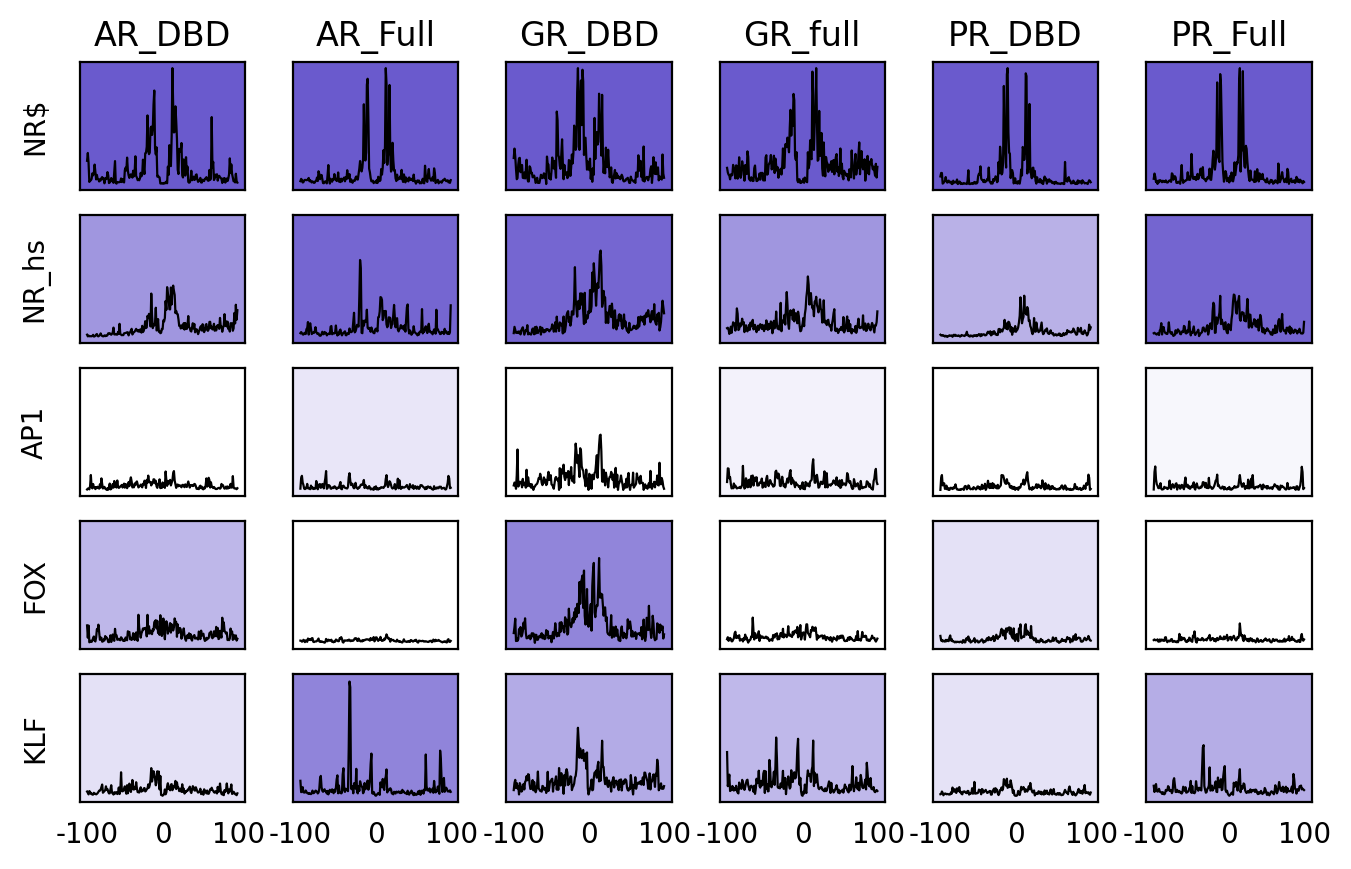

In [49]:
colormap = sns.blend_palette(['white', 'slateblue'], as_cmap=True)

fig = plt.figure()
subf = fig.subfigures(1,6)
for key, subfi in zip(['AR_DBD', 'AR_Full',  'GR_DBD', 'GR_full', 'PR_DBD', 'PR_Full'], subf):
    cdat = alldf.filter(regex=key)
    maxval = cdat.mean().max()
    minval = cdat.mean().min()
    
    norm = plt.Normalize(vmin=minval, vmax=maxval)
    axes = subfi.subplots(5,1, sharey=True, sharex=True)
    axes[0].set_title(key)
    for mot, axi in zip(['NR$', 'NR_hs', 'AP1', 'FOX', 'KLF'], axes):
        # pass
        to_plot = cdat.filter(regex=mot)
        background_color = colormap(norm(to_plot.mean()))
        axi.plot(to_plot, c='k', lw=.8)
        axi.set_facecolor(background_color)
        axi.set_yticklabels('')

        axi.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)

        axi.set_xticks(np.arange(0,300,100), np.arange(-100,200,100))
        if subfi == subf[0]:
            axi.set_ylabel(mot)
g.figure.savefig('figures/Fig7/7B_1.pdf')

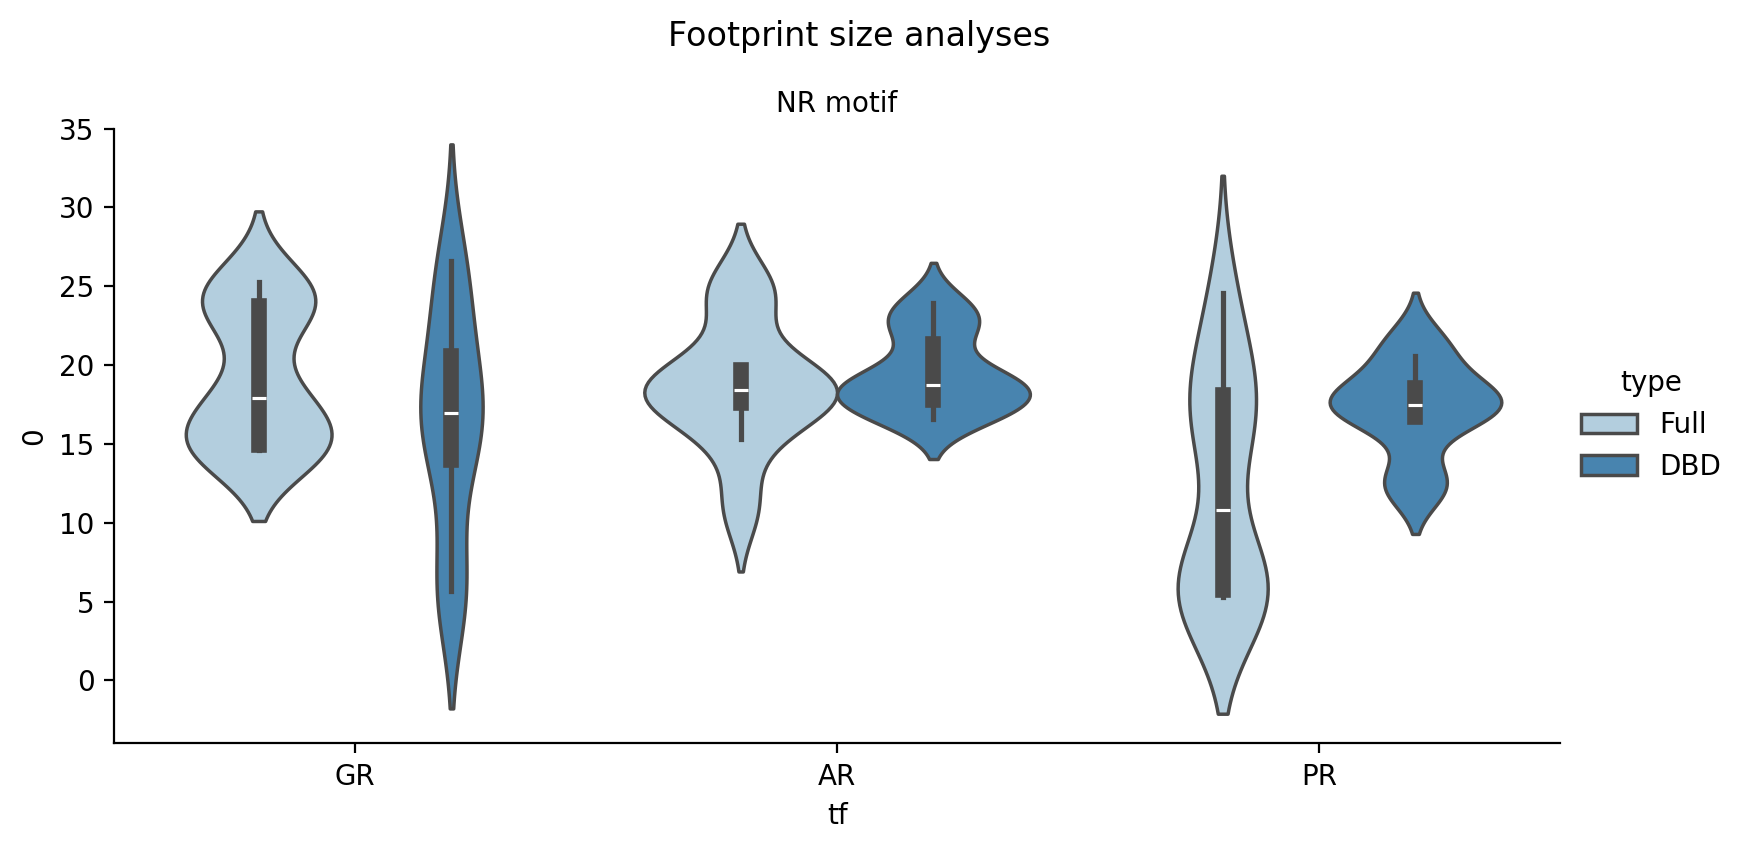

In [47]:
unstacked = allfoot_df.filter(regex='NR$').iloc[:10].unstack().reset_index()
unstacked.loc[:, 'motif'] = unstacked.level_0.apply(lambda x: x.split('_')[-1])
unstacked.loc[:, 'tf'] = unstacked.level_0.apply(lambda x: x.split('_')[0])
unstacked.loc[:, 'type'] = unstacked.level_0.apply(lambda x: x.split('_')[1])
unstacked = unstacked.drop('level_0', axis=1)
unstacked.replace('full', 'Full', inplace=True)


g = sns.catplot(
    unstacked.query("type=='Full' | type =='DBD'"), kind="violin",
    col="motif", y=0, x="tf", hue='type',
    height=4, aspect=2, sharey=True,native_scale=True, palette='Blues', bw_adjust=.8
)

g.set_titles("{col_name} {col_var}")
g.fig.suptitle("Footprint size analyses", y=1.05)  # Adjust y to control the vertical position
y_min, y_max = -4, 35  # Define your desired y-axis limits
for ax in g.axes.flat:
    ax.set_ylim(y_min, y_max)
g.figure.savefig('figures/Fig7/7B_2.pdf')

In [51]:
df_for_sp = pd.read_csv('data/yeast/jingdef.csv', index_col=0)


In [52]:
df_for_sp = df_for_sp.set_index('name')

/tmp/ipykernel_612127/3151911173.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tracks_maxes = tracks.applymap(lambda x: np.max(x)).quantile(0.2).to_dict()
/tmp/ipykernel_612127/3093407510.py:132: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genecoords = (gp.query("chr_loc==@chrom & start>@startchr & stop<@stopchr & status=='Verified ORF'").loc[:, ['start', 'stop']].applymap(lambda x: int(x)) - startchr).clip(0)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi.set_yticklabels(axi.get_yticklabels(), size=5)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi.set_yticklabels(axi.get_yticklabels(), size=5)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_

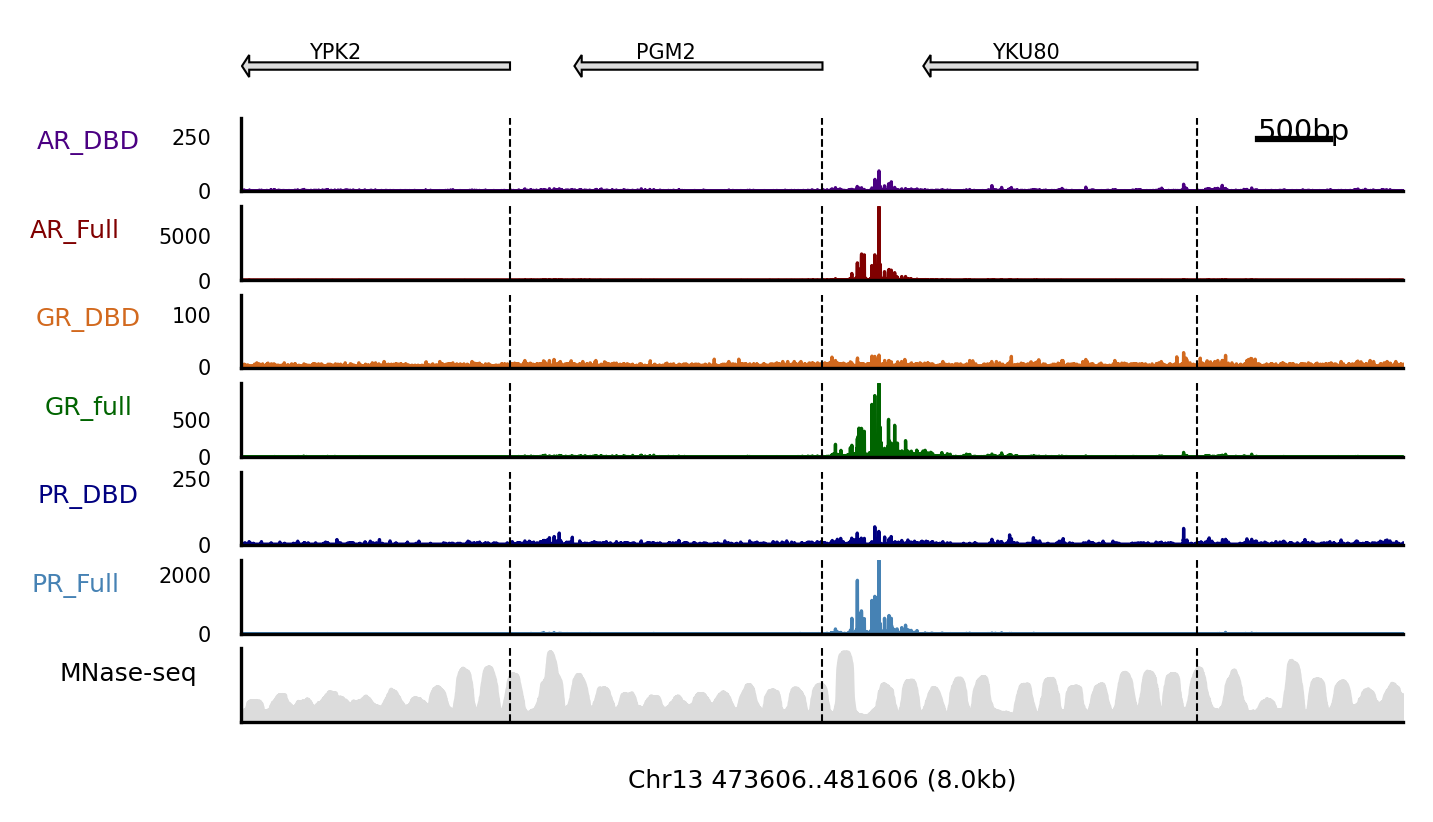

In [56]:

tracks_maxes = tracks.applymap(lambda x: np.max(x)).quantile(0.2).to_dict()
a,b = df_for_sp.loc['PGM2', ['Chromosome', 'TSS']].values.astype(int)
draw_promoter(a,b,tracks_maxes, mean_data=tracks.filter(regex='DBD|Full|full'),  title='', save='7E_1', gp=gp,)

/tmp/ipykernel_612127/3093407510.py:132: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genecoords = (gp.query("chr_loc==@chrom & start>@startchr & stop<@stopchr & status=='Verified ORF'").loc[:, ['start', 'stop']].applymap(lambda x: int(x)) - startchr).clip(0)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi.set_yticklabels(axi.get_yticklabels(), size=5)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi.set_yticklabels(axi.get_yticklabels(), size=5)
/tmp/ipykernel_612127/3093407510.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi.set_yticklabels(axi.get_yticklabels(), size=5)
/tmp/ipykernel_612127/3093407510.py

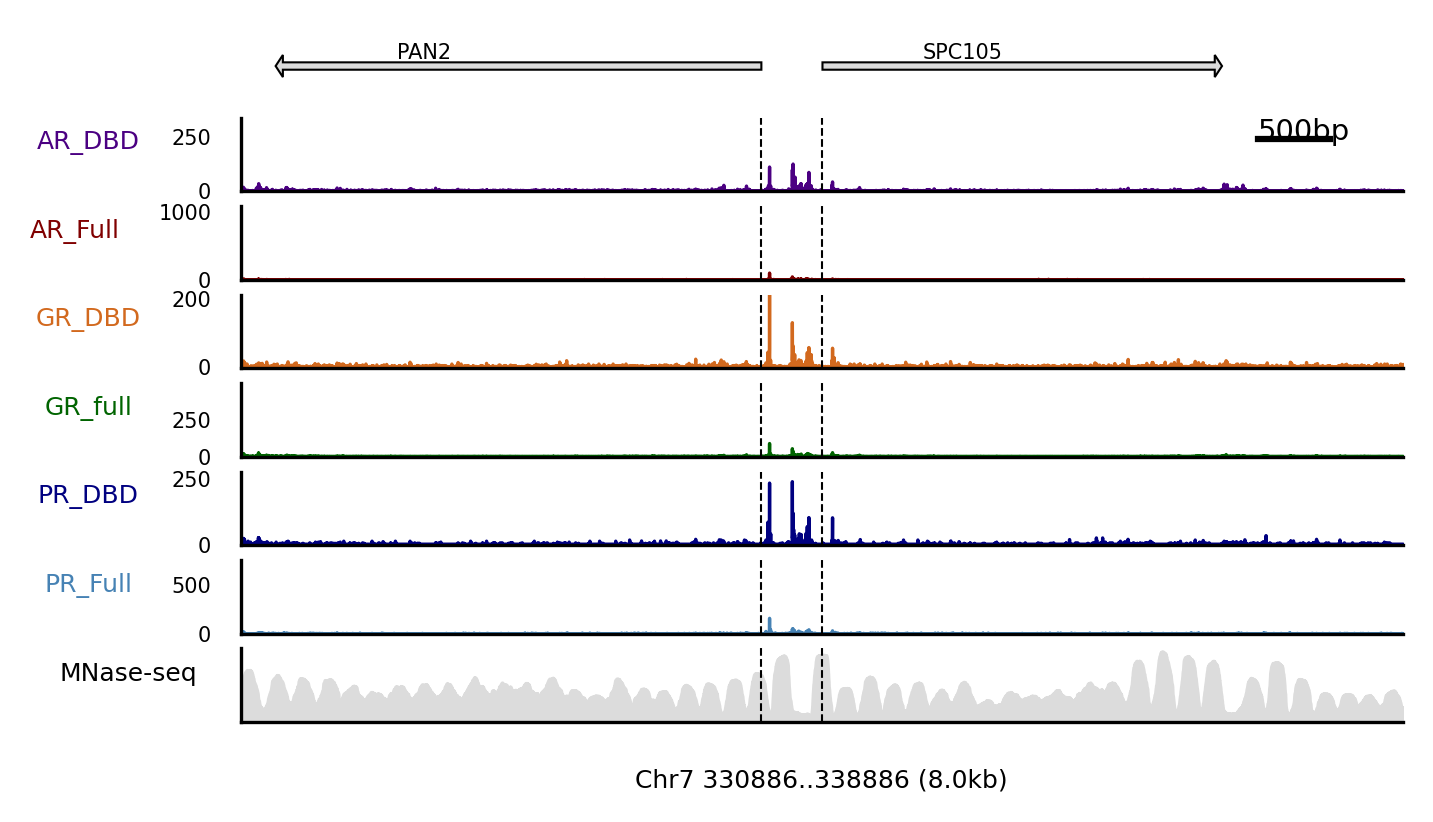

In [57]:

a,b = df_for_sp.loc['SPC105', ['Chromosome', 'TSS']].values.astype(int)
draw_promoter(a,b,tracks_maxes, mean_data=tracks.filter(regex='DBD|Full|full'),  title='', save='7E_2', gp=gp,)

/tmp/ipykernel_612127/2012302700.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dpn_pref = pd.DataFrame({0:dts}).applymap(lambda x: opn_vec.loc[x].values)
/tmp/ipykernel_612127/2012302700.py:9: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(pd.DataFrame({x:pd.Series(k) for x,k in dpn_pref.to_dict()[0].items()}), ax=ax, palette=sns.color_palette('GnBu', n_colors=2), showfliers=False,)


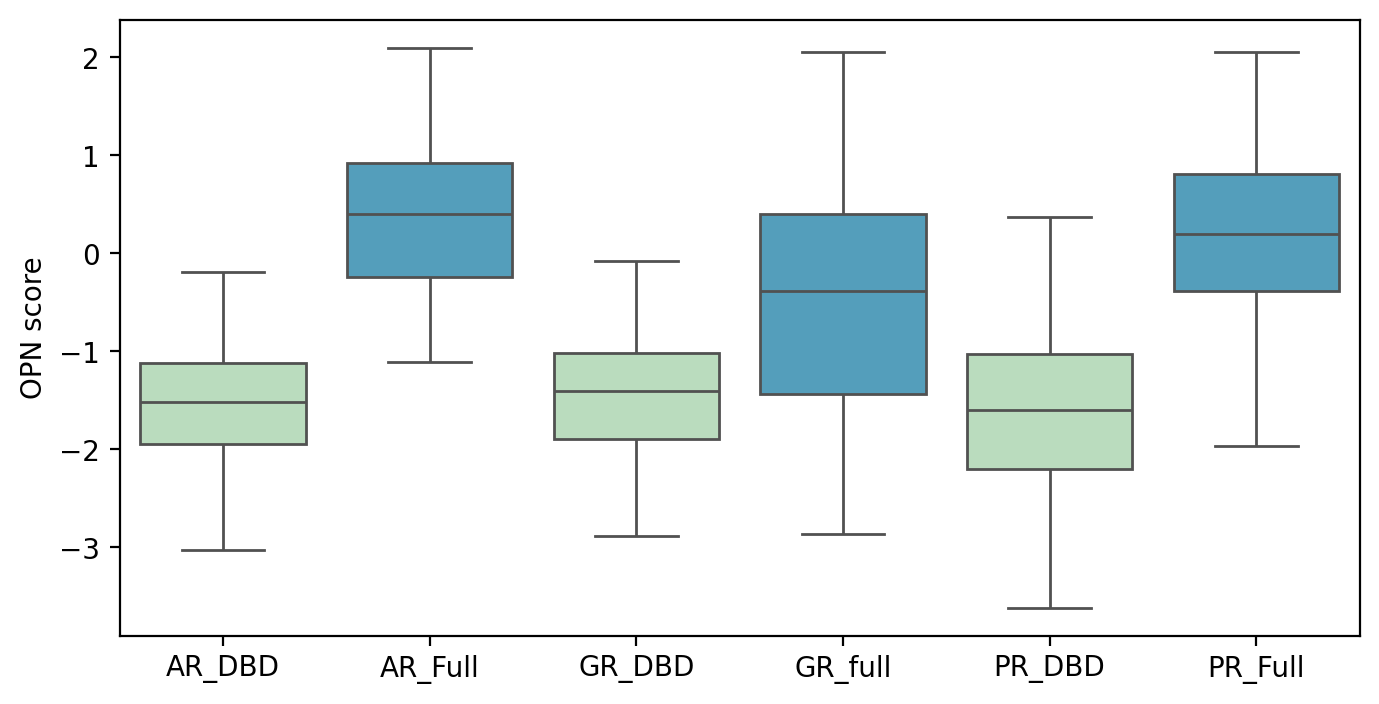

In [59]:
opn_vec = pd.read_csv('data/yeast/comp_gp.csv', index_col=0).set_index('name').iloc[:, -1]
zscored = ((mean_sp - mean_sp.mean()) / mean_sp.std()).filter(regex='DBD|Full|full')
dts = dict()
for tf in zscored.columns:
    dts[tf] = list(zscored.query("{}>=3".format(tf)).index)
    
dpn_pref = pd.DataFrame({0:dts}).applymap(lambda x: opn_vec.loc[x].values)
fig, ax = plt.subplots(1, figsize=(8,4))
sns.boxplot(pd.DataFrame({x:pd.Series(k) for x,k in dpn_pref.to_dict()[0].items()}), ax=ax, palette=sns.color_palette('GnBu', n_colors=2), showfliers=False,)
# sns.swarmplot(pd.DataFrame({x:pd.Series(k) for x,k in dpn_pref.to_dict()[0].items()}), ax=ax, palette=['gainsboro'], edgecolor='k', linewidth=.5)
ax.set_ylabel('OPN score')
fig.savefig('figures/Fig7/7F.pdf')

,GR_full,GR_full,GR_full,GR_full,GR_1_60,GR_1_60,GR_1_60,GR_160_240,GR_160_240,GR_200_260,GR_200_260,GR_240_300,GR_240_300,GR_320_380,GR_320_380,GR_320_380,GR_DBD,GR_DBD
name,,,,,,,,,,,,,,,,,,
TFC3,323.384264,312.658445,313.078076,258.572747,364.713472,408.859394,389.325834,370.733964,417.814217,660.641309,444.304607,394.290147,412.739717,465.877207,507.035286,519.729538,296.120286,505.639844
VPS8,995.569085,957.217356,884.343917,688.200673,1407.666034,1155.107590,1041.167780,1707.623108,973.121016,913.167147,1005.334814,899.470203,1151.330939,930.404300,1219.833049,1030.148122,435.071127,629.525763
EFB1,1586.468619,1490.524168,1464.588728,1496.007306,2267.971019,1823.555097,1677.633967,2233.391276,2526.975542,2692.086992,1848.600165,2058.041523,1513.296133,760.172598,763.044503,826.842447,808.960377,856.392595
SSA1,1501.747641,1415.314233,1443.242496,1430.711158,2335.155080,1787.576336,1651.685358,2264.847491,2457.392158,2845.744926,1921.257106,2194.304547,1501.699994,737.572872,723.983891,754.038709,637.651121,868.864332
ERP2,1292.248672,1215.177666,1253.430441,1132.794891,1080.703605,1347.093505,1495.606894,1176.462447,1073.886128,1112.659046,832.826477,979.080028,1033.215980,1272.687421,1454.300533,1299.323845,502.507152,564.435175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NBL1,1519.511717,1476.849635,1660.262526,1520.674740,1832.292565,1954.214808,1629.121351,2159.993440,1142.632419,2556.868011,1287.065809,2236.593071,1808.997676,1483.363827,2002.083433,1740.356010,1065.924261,864.707086
YHR212W-A,373.631221,270.755766,261.643821,269.517625,397.345731,314.232547,327.629391,583.288104,735.491142,631.665813,370.906269,376.569242,524.808117,580.167249,572.127654,562.223148,484.560468,521.318599
YHR213W-B,2076.874237,1692.223540,1785.663171,2045.324109,1777.498292,1522.956607,1647.720540,756.297287,770.021243,585.305019,653.734532,553.778296,552.141873,560.796055,634.650586,715.853892,556.347204,509.559533


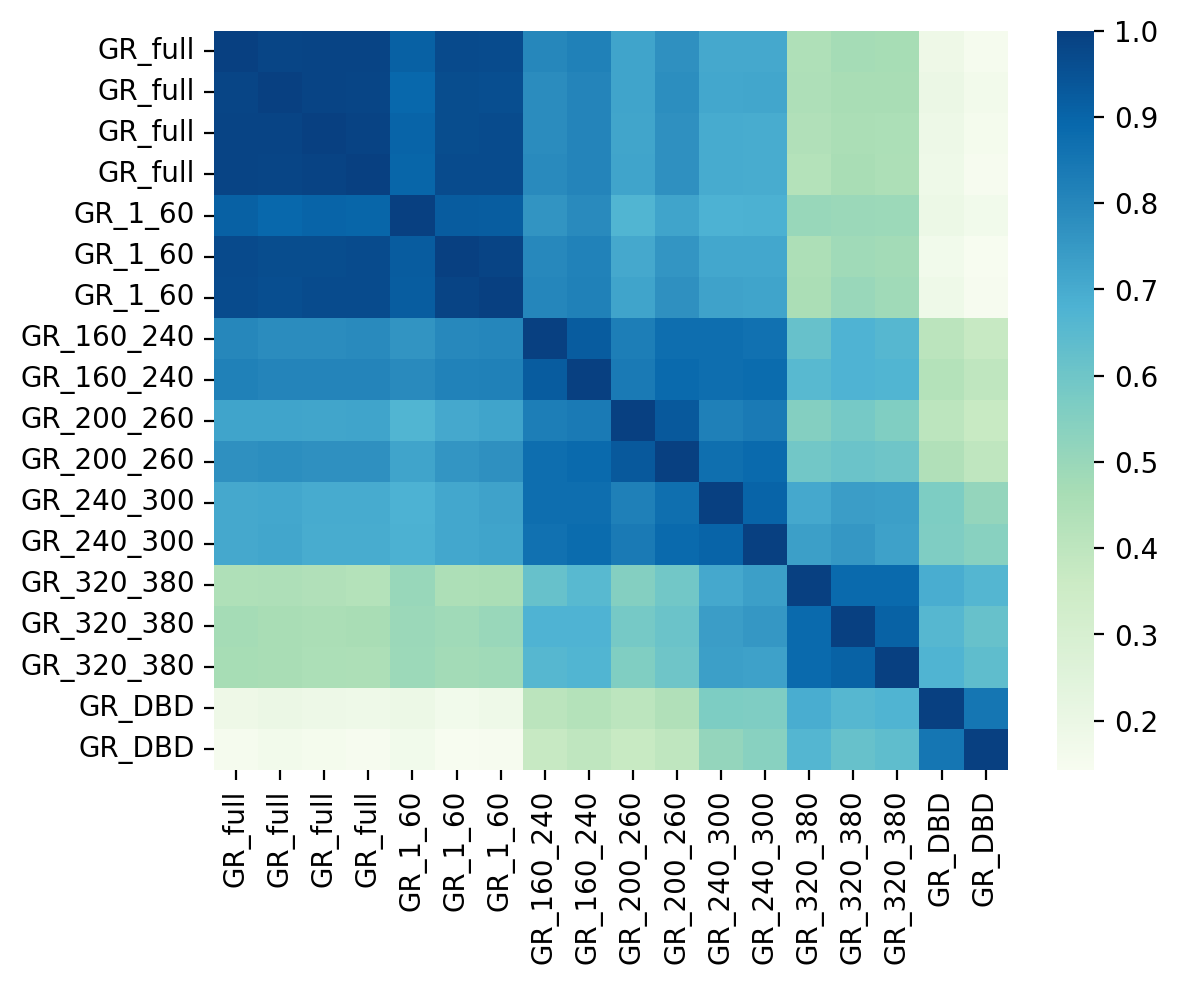

In [67]:
fig, ax = plt.subplots(1)
sns.heatmap(complete_set_reps.loc[:, ['GR_full','GR_1_60',  'GR_160_240', 'GR_200_260',
                                      'GR_240_300', 'GR_320_380', 'GR_DBD']].corr(), cmap='GnBu', ax=ax)
fig.savefig('figures/Fig7/7H.pdf')

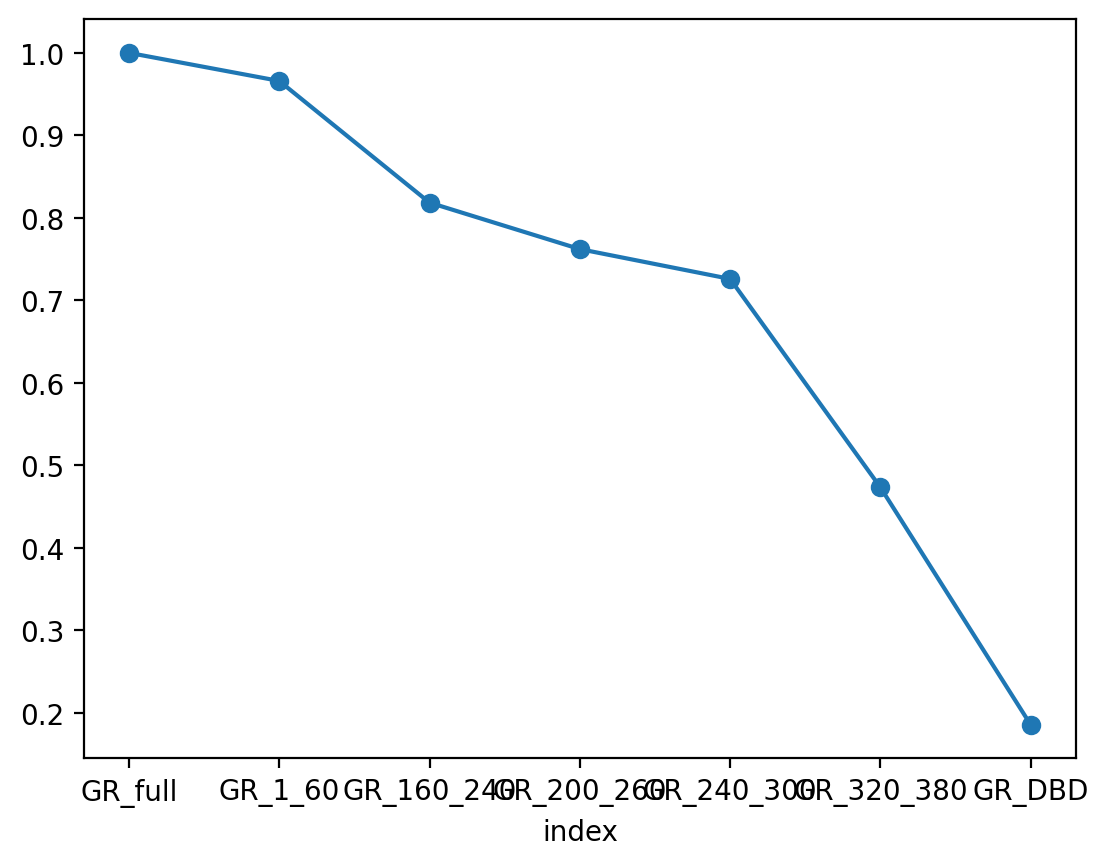

In [73]:
fig, ax = plt.subplots(1)

mean_sp.loc[:, ['GR_full','GR_1_60',  'GR_160_240', 'GR_200_260',
                                      'GR_240_300', 'GR_320_380', 'GR_DBD']].corr().iloc[:, 0].plot(marker='o', ax=ax)
fig.savefig('figures/Fig7/7H_2.pdf')